<a href="https://colab.research.google.com/github/lavanyasaxena01/Chest-Xray-IEL-Framewok/blob/main/IEL_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Setup**

In [ ]:
!pip install -q torch torchvision matplotlib pillow scikit-learn numpy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Classroom', 'Untitled (1).gdoc', 'Untitled.gdoc', 'Role Play', 'Crafting Sustainable Solutions for Cleaner, Healthier Air in Delhi.gdoc', 'DREAMVERSE IDEA.pdf', 'DREAMVERSE QNA.gdoc', 'Colab Notebooks', 'SIH Seminar Registration by Department of AI&DS (Responses).gsheet', 'fods file-1 (3).pdf', 'Embedded systems..gdoc', 'Lavanya Registration ss.jpg', 'lavanya saxena.jpg', 'lavanya.jpg', 'ThriveMiles.gsheet', 'Lavanya Saxena ', 'IMG-20251012-WA0037.jpg', 'E2 code list.gdoc', 'Screenshot_20251021-144656.jpg', 'Untitled document (15).gdoc', 'Screenshot_20251030-232721.jpg', 'Untitled document (14).gdoc', 'fods file-1 (3).gdoc', 'final DS_PRACTICAL_FILE ipu.gdoc', 'AegisAI.pptx', 'Untitled spreadsheet.gsheet', 'Utkarsh event .gdoc', 'Business Monopoly – Fest Edition (2).gdoc', 'Business Monopoly – Fest Edition (1).gdoc', 'Business Monopoly – Fest Edition.gdoc', 'Untitled document (13).gdoc', 'CareerSense AI- An Intelligent Career Guidance & Skill Recommendation System.gdoc', 'IMG-2026021

In [ ]:
data_dir = "/content/drive/MyDrive/chest_xray"

In [ ]:
import os
print(os.listdir(data_dir))

['__MACOSX', 'train', 'test', 'val', 'chest_xray']


In [ ]:
train_dir = os.path.join(data_dir, "train")
test_dir  = os.path.join(data_dir, "test")
val_dir   = os.path.join(data_dir, "val")

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/chest_xray"

## 1 · Model architecture (paper-faithful)

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import models, transforms

CONCEPTS = ['lung_opacity', 'pleural_effusion', 'cardiomegaly', 'consolidation']

class SSLEncoder(nn.Module):
    def __init__(self, projection_dim=128, pretrained=True):
        super().__init__()
        bb = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.feature_dim = bb.fc.in_features
        bb.fc = nn.Identity()
        self.encoder = bb
        self.projector = nn.Sequential(
            nn.Linear(2048, 512), nn.ReLU(inplace=True), nn.Linear(512, projection_dim))
    def forward(self, x):
        h = self.encoder(x); z = F.normalize(self.projector(h), dim=-1)
        return h, z

def nt_xent_loss(z1, z2, t=0.5):
    B = z1.size(0); z = torch.cat([z1, z2], 0)
    sim = (z @ z.t()) / t
    sim.masked_fill_(torch.eye(2*B, dtype=torch.bool, device=z.device), float('-inf'))
    tgt = torch.arange(2*B, device=z.device); tgt = (tgt + B) % (2*B)
    return F.cross_entropy(sim, tgt)

class ConceptBottleneckClassifier(nn.Module):
    def __init__(self, enc, num_concepts=4, num_classes=2):
        super().__init__()

        self.encoder = enc
        for p in self.encoder.parameters(): p.requires_grad = False
        self.concept_layer = nn.Linear(enc.feature_dim, num_concepts)
        self.classifier   = nn.Linear(num_concepts, num_classes)
    def forward(self, x, return_all=False):
        feats = self.encoder.encoder(x)
        c = torch.sigmoid(self.concept_layer(feats))
        y = self.classifier(c)
        return (y, c, feats) if return_all else y

## 2 · Data pipeline

In [ ]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import os, numpy as np

NORM_MEAN, NORM_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
ssl_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize(NORM_MEAN, NORM_STD)])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)])

def list_samples(root):
    samples = []; cls = sorted([d.name for d in Path(root).iterdir() if d.is_dir()])
    c2i = {c:i for i,c in enumerate(cls)}
    for c in cls:
        for f in (Path(root)/c).iterdir():
            if f.suffix.lower() in ('.jpg','.jpeg','.png'): samples.append((str(f), c2i[c]))
    return samples, c2i

class SSLPair(Dataset):
    def __init__(self, root): self.s, _ = list_samples(root)
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        img = Image.open(self.s[i][0]).convert('RGB')
        return ssl_tf(img), ssl_tf(img)

class Labeled(Dataset):
    def __init__(self, root, train=False):
        self.s, self.c2i = list_samples(root)
        self.tf = ssl_tf if train else eval_tf
        self.i2c = {v:k for k,v in self.c2i.items()}
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        p, y = self.s[i]; img = Image.open(p).convert('RGB')
        return self.tf(img), torch.tensor(y), p

## 3 · Training — Stage 1 (SSL) and Stage 2 (CBM)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using', device)

encoder = SSLEncoder(pretrained=True).to(device)
DATA_ROOT = "/content/drive/MyDrive/chest_xray"

# --- Stage 1 ---
ssl_dl = DataLoader(SSLPair(f'{DATA_ROOT}/train'), batch_size=16, shuffle=True, drop_last=True, num_workers=2)
opt = torch.optim.Adam(encoder.parameters(), lr=1e-4)
encoder.train()
for ep in range(2):
    tot, n = 0, 0
    for v1, v2 in ssl_dl:
        v1, v2 = v1.to(device), v2.to(device)
        _, z1 = encoder(v1); _, z2 = encoder(v2)
        l = nt_xent_loss(z1, z2, 0.5)
        opt.zero_grad(); l.backward(); opt.step()
        tot += l.item(); n += 1
    print(f'[SSL] epoch {ep+1} loss = {tot/n:.4f}')

# --- Stage 2 ---
model = ConceptBottleneckClassifier(encoder).to(device)
tr_dl = DataLoader(Labeled(f'{DATA_ROOT}/train', train=True),  batch_size=16, shuffle=True, num_workers=2)
va_dl = DataLoader(Labeled(f'{DATA_ROOT}/val',   train=False), batch_size=16, num_workers=2)
opt2 = torch.optim.Adam(list(model.concept_layer.parameters())+list(model.classifier.parameters()), lr=1e-4)
crit = nn.CrossEntropyLoss()
for ep in range(3):
    model.train(); model.encoder.eval()
    for x, y, _ in tr_dl:
        x, y = x.to(device), y.to(device)
        l = crit(model(x), y)
        opt2.zero_grad(); l.backward(); opt2.step()
    print(f'[CBM] epoch {ep+1} done')

torch.save(model.state_dict(), 'iel_checkpoint.pt')

Using cuda
[SSL] epoch 1 loss = 1.8865
[SSL] epoch 2 loss = 1.6566
[CBM] epoch 1 done
[CBM] epoch 2 done
[CBM] epoch 3 done


## 4 · Evaluation (accuracy / precision / recall / F1 / AUC)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
te_dl = DataLoader(Labeled(f'{DATA_ROOT}/test', train=False), batch_size=16, num_workers=2)
model.eval(); y_true, y_pred, y_score = [], [], []
with torch.no_grad():
    for x, y, _ in te_dl:
        x = x.to(device); logits = model(x)
        p = torch.softmax(logits, 1)[:, 1].cpu().numpy()
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_score.extend(p); y_true.extend(y.numpy())
print(f'Accuracy : {accuracy_score(y_true, y_pred):.3f}')
print(f'Precision: {precision_score(y_true, y_pred):.3f}')
print(f'Recall   : {recall_score(y_true, y_pred):.3f}')
print(f'F1       : {f1_score(y_true, y_pred):.3f}')
print(f'AUC      : {roc_auc_score(y_true, y_score):.3f}')

Accuracy : 0.841
Precision: 0.810
Recall   : 0.974
F1       : 0.885
AUC      : 0.907


## 5 · Intrinsic + post-hoc explanation on a single X-ray

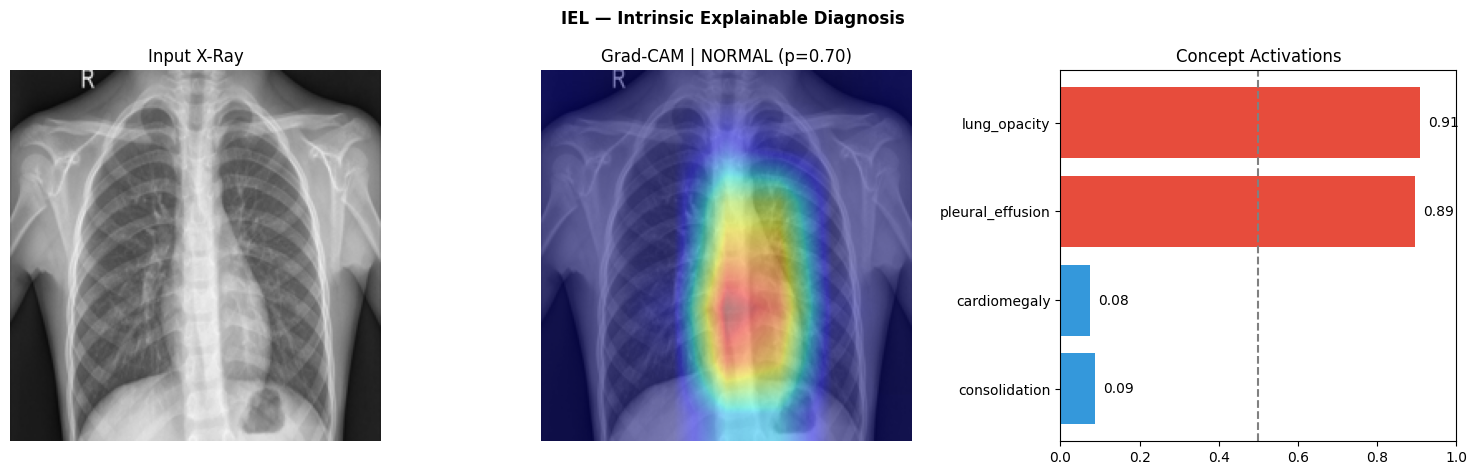

In [ ]:
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, m):
        self.m = m; self.a, self.g = None, None
        self.tgt = m.encoder.encoder.layer4[-1]
        self.tgt.register_forward_hook(lambda mod,i,o: setattr(self,'a',o.detach()))
        self.tgt.register_full_backward_hook(lambda mod,gi,go: setattr(self,'g',go[0].detach()))
    def __call__(self, x, cls):
        self.m.eval()
        for p in self.m.parameters(): p.requires_grad_(True)
        out = self.m(x); self.m.zero_grad(); out[0, cls].backward()
        w = self.g.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w*self.a).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min())/(cam.max()-cam.min()+1e-8)

# Pick a test image
te = Labeled(f'{DATA_ROOT}/test', train=False)
img_t, label, path = te[0]
img_pil = Image.open(path).convert('RGB').resize((224,224))
x = img_t.unsqueeze(0).to(device)

with torch.no_grad():
    logits, c, feats = model(x, return_all=True)
probs = torch.softmax(logits,1).squeeze().cpu().numpy()
cvec = c.squeeze().cpu().numpy(); pred = int(probs.argmax())
cam = GradCAM(model)(x, pred)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))
ax[0].imshow(img_pil); ax[0].set_title('Input X-Ray'); ax[0].axis('off')
ax[1].imshow(img_pil); ax[1].imshow(cam, cmap='jet', alpha=0.45)
ax[1].set_title(f"Grad-CAM | {te.i2c[pred]} (p={probs[pred]:.2f})"); ax[1].axis('off')
colors = ['#e74c3c' if v>.5 else '#3498db' for v in cvec]
ax[2].barh(CONCEPTS, cvec, color=colors); ax[2].set_xlim(0,1); ax[2].invert_yaxis()
ax[2].axvline(0.5, ls='--', c='gray'); ax[2].set_title('Concept Activations')
for i,v in enumerate(cvec): ax[2].text(v+.02, i, f'{v:.2f}', va='center')
plt.suptitle('IEL — Intrinsic Explainable Diagnosis', fontweight='bold')
plt.tight_layout(); plt.show()

## 6 · Prototype retrieval (3 most-similar training cases)

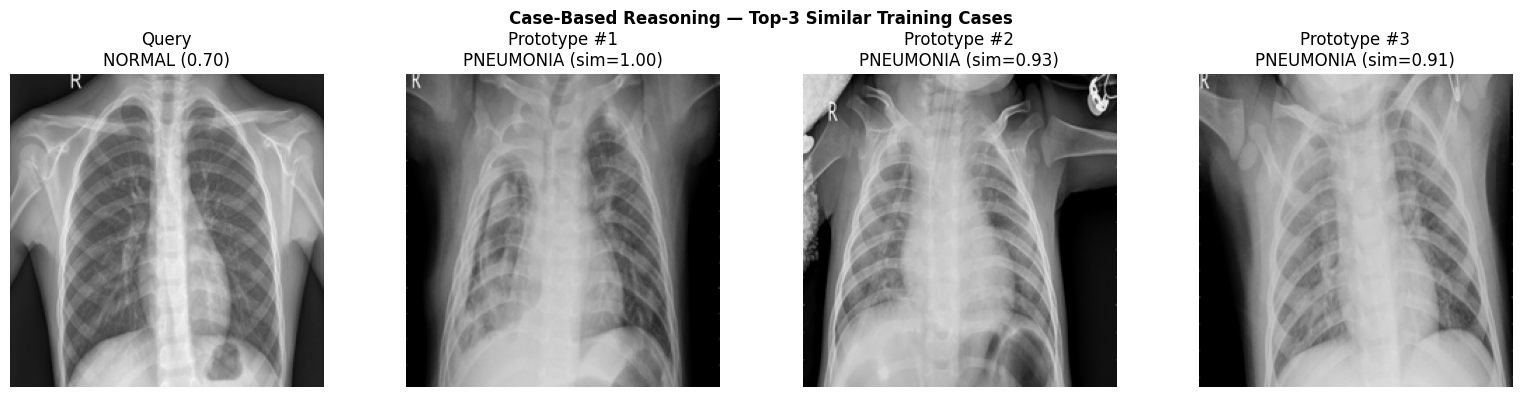

In [ ]:
# Build bank
tr_eval = DataLoader(Labeled(f'{DATA_ROOT}/train', train=False), batch_size=16, num_workers=2)
feats_bank, labels_bank, paths_bank = [], [], []
model.eval()
with torch.no_grad():
    for x, y, p in tr_eval:
        f = model.encoder.encoder(x.to(device))
        f = F.normalize(f, dim=-1).cpu()
        feats_bank.append(f); labels_bank.append(y); paths_bank.extend(p)
feats_bank = torch.cat(feats_bank); labels_bank = torch.cat(labels_bank)

# Query
# Take only first image from batch
x = x[0].unsqueeze(0).to(device)

with torch.no_grad():
    q = F.normalize(model.encoder.encoder(x), dim=-1).cpu()

# Similarities
sims = (q @ feats_bank.t()).numpy()[0]

# Top-3 nearest prototypes
top3 = sims.argsort()[::-1][:3]

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_pil); ax[0].set_title(f'Query\n{te.i2c[pred]} ({probs[pred]:.2f})'); ax[0].axis('off')
for j, idx in enumerate(top3.flatten()):

    idx = int(idx)

    p_img = Image.open(paths_bank[idx]).convert('RGB').resize((224,224))

    ax[j+1].imshow(p_img)

    ax[j+1].set_title(
        f'Prototype #{j+1}\n{te.i2c[int(labels_bank[idx])]} (sim={sims[idx]:.2f})'
    )

    ax[j+1].axis('off')
plt.suptitle('Case-Based Reasoning — Top-3 Similar Training Cases', fontweight='bold')
plt.tight_layout(); plt.show()